In [40]:
import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sqlalchemy import create_engine
import datetime
import utils

In [41]:
load_dotenv()
# f"postgres+psycopg2://{[user]}:{[pass]}@{[host}:{[port]}/{[dbname]}"
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}"
    f"@{os.getenv('POSTGRES_HOST')}:{os.getenv('POSTGRES_PORT')}/{os.getenv('POSTGRES_DB')}"
)

In [42]:
query_min = "SELECT * FROM gold.active_1min"
df_min = pd.read_sql(query_min,engine)

In [43]:
df_min['bucket_30min'] = df_min['bar_time'].apply(
    lambda t: (
        datetime.datetime.min + datetime.timedelta(minutes=(t.hour*60 + t.minute)//30 *30)  
    ).time() 
)

df_min['bucket_hr'] = df_min['bar_time'].apply( lambda t: datetime.time(t.hour,0,0))

In [44]:
df_min['price_movement'] = (df_min['high']-df_min['low']).abs()
df_day = df_min.groupby('bar_date')['price_movement'].agg('sum').reset_index()
df_hr = df_min.groupby(['bar_date','bucket_hr'])['price_movement'].agg('sum').reset_index()
df_30 = df_min.groupby(['bar_date','bucket_30min'])['price_movement'].agg('sum').reset_index()

Daily Analysis

In [45]:
utils.get_basic_info(df_day,'price_movement')

count     229.000000
mean     1356.941048
std       875.307329
min        99.750000
25%       840.500000
50%      1154.500000
75%      1575.250000
max      7495.250000
Name: price_movement, dtype: float64
Median:  1154.5
Std Dev:  875.3073290583616
IQR: 734.75


In [46]:
df_day[df_day['price_movement']<500]

,bar_date,price_movement
118,2025-07-01,99.75
120,2025-07-03,420.25


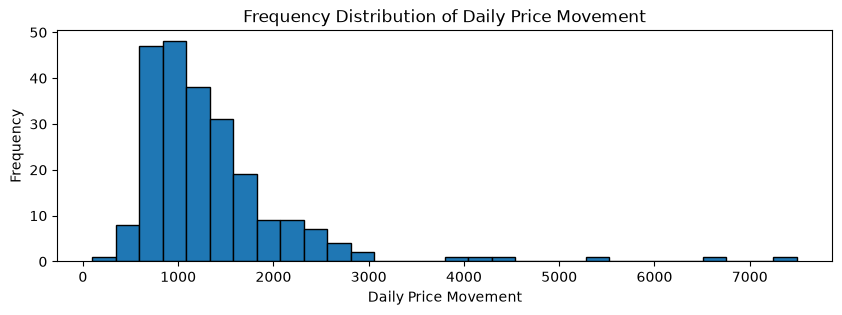

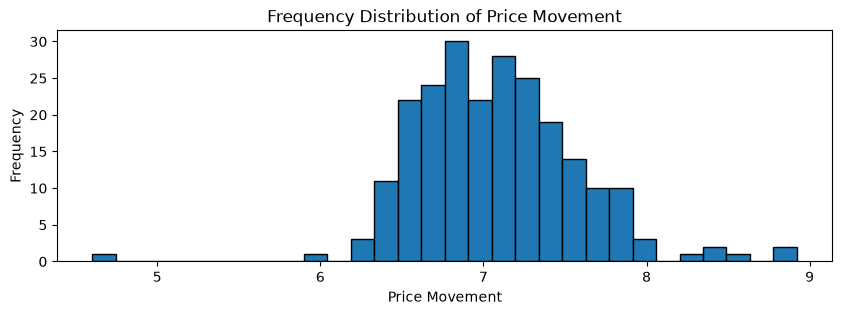

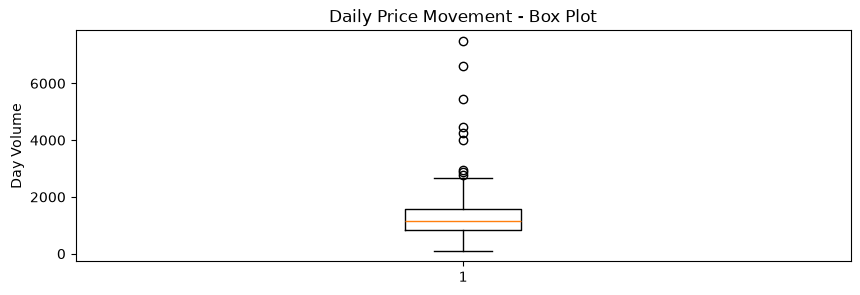

In [47]:
utils.frequency_hist(df_day,'price_movement',30,'Daily Price Movement')

df_day['log_price_movement'] = np.log(df_day['price_movement'])
utils.frequency_hist(df_day,'log_price_movement',30,'Price Movement')

utils.box_plot(df_day,'price_movement','Day Volume', 'Daily Price Movement - Box Plot')

Hour Analysis

In [48]:
agg_hr = df_hr.groupby('bucket_hr')['price_movement'].agg(['mean','median','std'])
df_hr['q1'] = df_hr.groupby('bucket_hr')['price_movement'].transform(lambda x: x.quantile(.25))
df_hr['q3'] = df_hr.groupby('bucket_hr')['price_movement'].transform(lambda x: x.quantile(.75))
df_hr_IQR = df_hr[(df_hr['price_movement']>=df_hr['q1'])&(df_hr['price_movement']<=df_hr['q3'])]
agg_hr_IQR = df_hr_IQR.groupby('bucket_hr')['price_movement'].agg(['mean','median','std'])

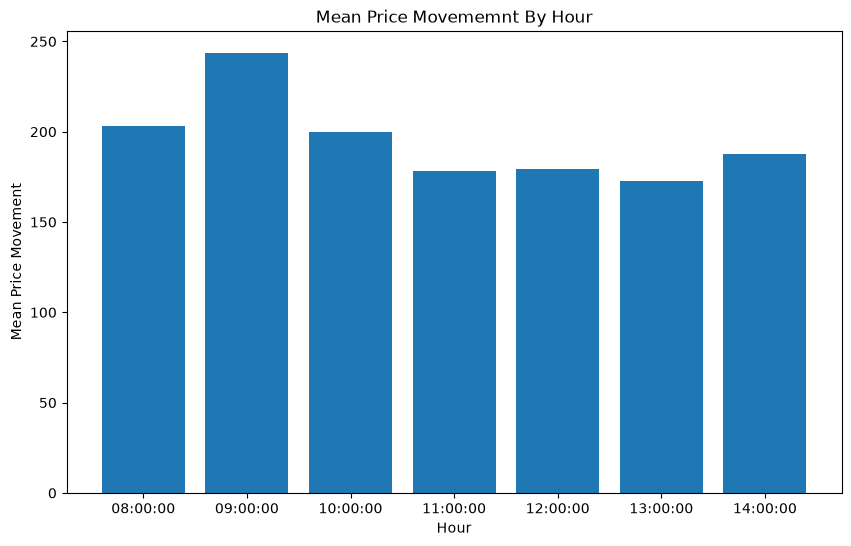

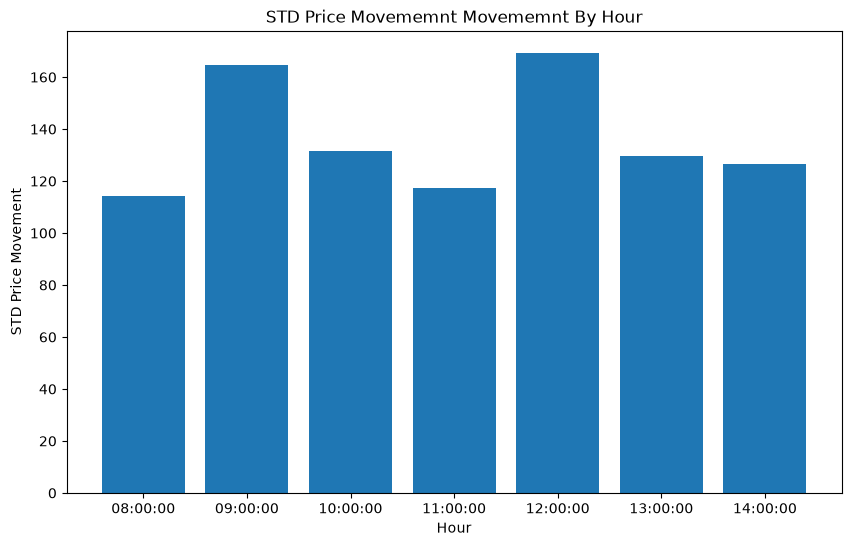

In [49]:
plt.figure(figsize=(10,6))
plt.bar(agg_hr.index.astype(str),agg_hr['mean'])
plt.xlabel('Hour')
plt.ylabel('Mean Price Movement')
plt.title('Mean Price Movememnt By Hour')

plt.show()


plt.figure(figsize=(10,6))
plt.bar(agg_hr.index.astype(str),agg_hr['std'])
plt.xlabel('Hour')
plt.ylabel('STD Price Movement')
plt.title('STD Price Movememnt Movememnt By Hour')

plt.show()

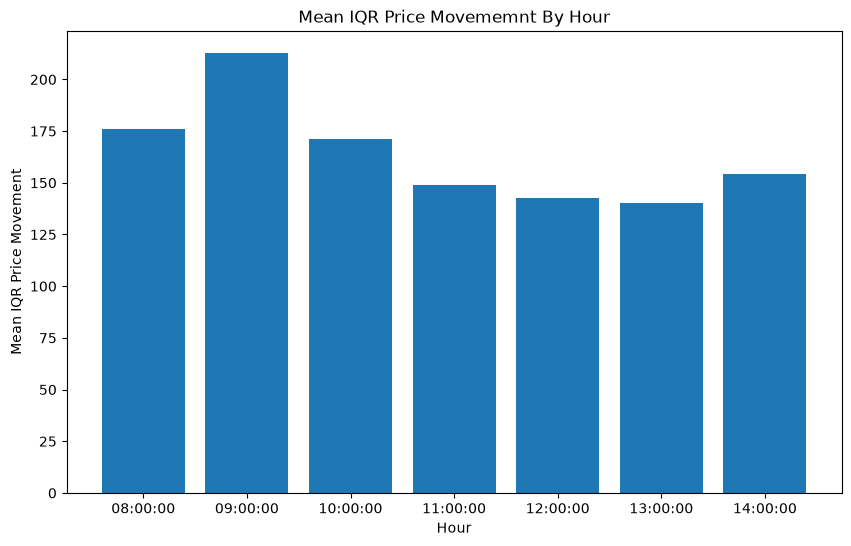

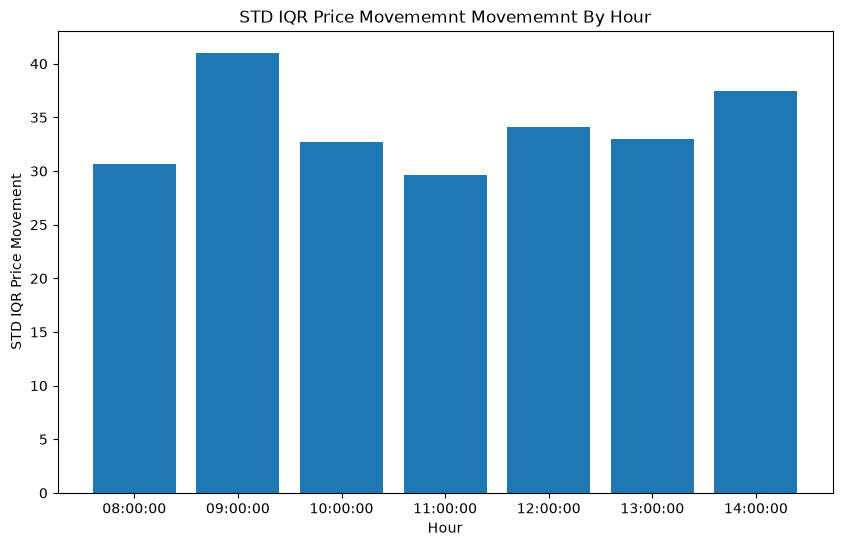

In [50]:
plt.figure(figsize=(10,6))
plt.bar(agg_hr_IQR.index.astype(str),agg_hr_IQR['mean'])
plt.xlabel('Hour')
plt.ylabel('Mean IQR Price Movement')
plt.title('Mean IQR Price Movememnt By Hour')

plt.show()

plt.figure(figsize=(10,6))
plt.bar(agg_hr_IQR.index.astype(str),agg_hr_IQR['std'])
plt.xlabel('Hour')
plt.ylabel('STD IQR Price Movement')
plt.title('STD IQR Price Movememnt Movememnt By Hour')

plt.show()

30 Minute Analysis

In [51]:
agg_30 = df_30.groupby('bucket_30min')['price_movement'].agg(['mean','median','std'])
df_30['q1'] = df_30.groupby('bucket_30min')['price_movement'].transform(lambda x: x.quantile(.25))
df_30['q3'] = df_30.groupby('bucket_30min')['price_movement'].transform(lambda x: x.quantile(.75))
df_30_IQR = df_30[(df_30['price_movement']>=df_30['q1'])&(df_30['price_movement']<=df_30['q3'])]
agg_30_IQR = df_30_IQR.groupby('bucket_30min')['price_movement'].agg(['mean','median','std'])

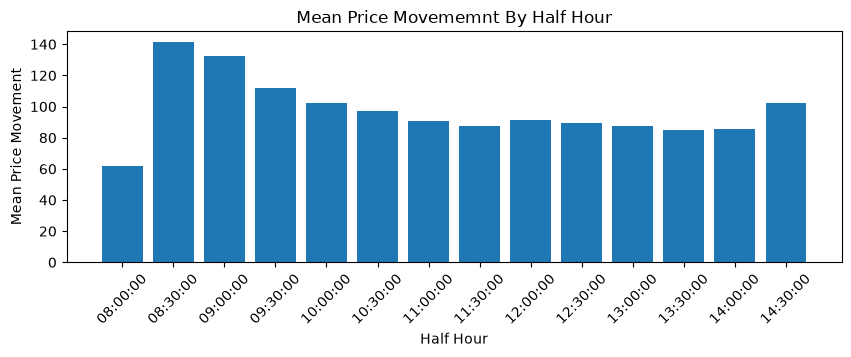

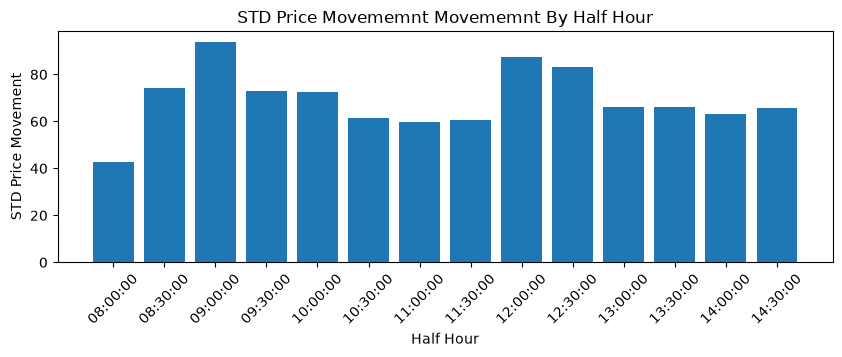

In [52]:
plt.figure(figsize=(10,3))
plt.bar(agg_30.index.astype(str),agg_30['mean'])
plt.xlabel('Half Hour')
plt.ylabel('Mean Price Movement')
plt.title('Mean Price Movememnt By Half Hour')
ax = plt.gca()
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,3))
plt.bar(agg_30.index.astype(str),agg_30['std'])
plt.xlabel('Half Hour')
plt.ylabel('STD Price Movement')
plt.title('STD Price Movememnt Movememnt By Half Hour')
ax = plt.gca()
plt.xticks(rotation=45)
plt.show()

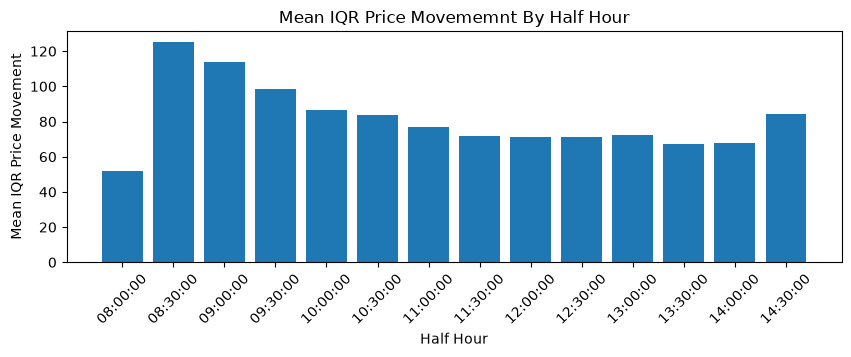

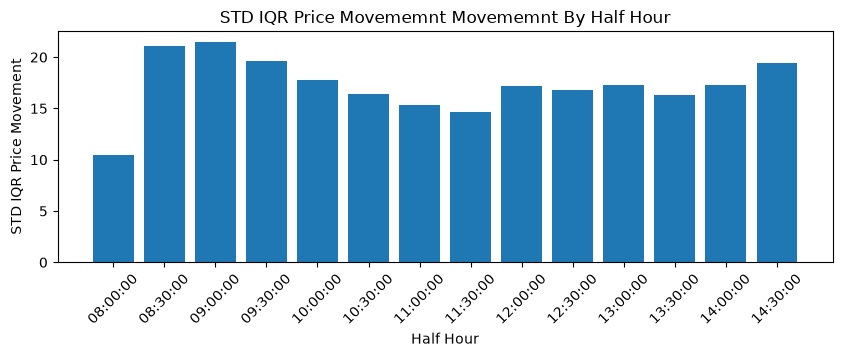

In [53]:
plt.figure(figsize=(10,3))
plt.bar(agg_30_IQR.index.astype(str),agg_30_IQR['mean'])
plt.xlabel('Half Hour')
plt.ylabel('Mean IQR Price Movement')
plt.title('Mean IQR Price Movememnt By Half Hour')
ax = plt.gca()
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,3))
plt.bar(agg_30_IQR.index.astype(str),agg_30_IQR['std'])
plt.xlabel('Half Hour')
plt.ylabel('STD IQR Price Movement')
plt.title('STD IQR Price Movememnt Movememnt By Half Hour')
ax = plt.gca()
plt.xticks(rotation=45)
plt.show()

Minute Analysis

In [54]:
agg_min = df_min.groupby('bar_time')['price_movement'].agg(['mean','median','std'])
df_min['q1'] = df_min.groupby('bar_time')['price_movement'].transform(lambda x: x.quantile(.25))
df_min['q3'] = df_min.groupby('bar_time')['price_movement'].transform(lambda x: x.quantile(.75))
df_min_IQR = df_min[(df_min['price_movement']>=df_min['q1'])&(df_min['price_movement']<=df_min['q3'])]
agg_min_IQR = df_min_IQR.groupby('bar_time')['price_movement'].agg(['mean','median','std'])

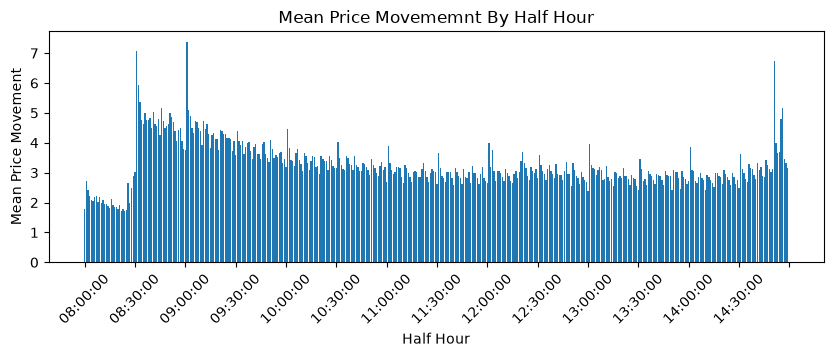

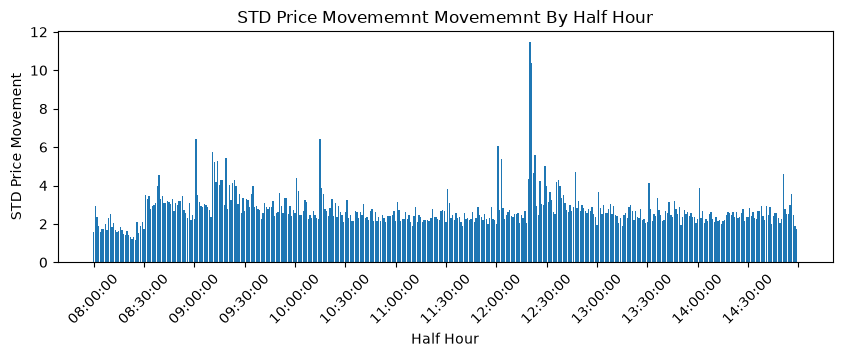

In [55]:
plt.figure(figsize=(10,3))
plt.bar(agg_min.index.astype(str),agg_min['mean'])
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=16))
plt.xlabel('Half Hour')
plt.ylabel('Mean Price Movement')
plt.title('Mean Price Movememnt By Half Hour')
ax = plt.gca()
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,3))
plt.bar(agg_min.index.astype(str),agg_min['std'])
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=16))
plt.xlabel('Half Hour')
plt.ylabel('STD Price Movement')
plt.title('STD Price Movememnt Movememnt By Half Hour')
ax = plt.gca()
plt.xticks(rotation=45)
plt.show()

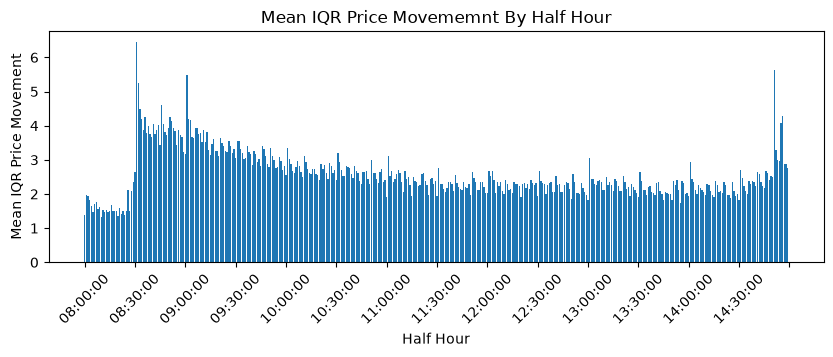

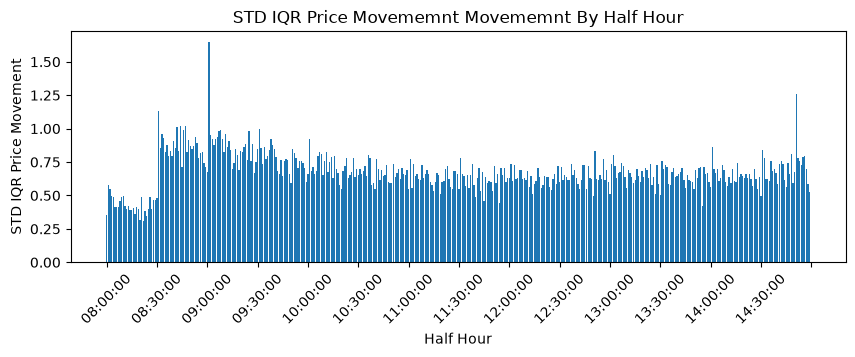

In [56]:
plt.figure(figsize=(10,3))
plt.bar(agg_min_IQR.index.astype(str),agg_min_IQR['mean'])
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=16))
plt.xlabel('Half Hour')
plt.ylabel('Mean IQR Price Movement')
plt.title('Mean IQR Price Movememnt By Half Hour')
ax = plt.gca()
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,3))
plt.bar(agg_min_IQR.index.astype(str),agg_min_IQR['std'])
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=16))
plt.xlabel('Half Hour')
plt.ylabel('STD IQR Price Movement')
plt.title('STD IQR Price Movememnt Movememnt By Half Hour')
ax = plt.gca()
plt.xticks(rotation=45)
plt.show()